In [25]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
from idtxl.estimators_jidt import JidtDiscreteMI, JidtDiscreteCMI
import dit
import matplotlib.pyplot as plt
import os, sys
os.environ['JAVA_HOME'] = '/Users/jaime/miniconda3/envs/ma-aif-dit/lib/jvm'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
%store -r all_partition_timeseries

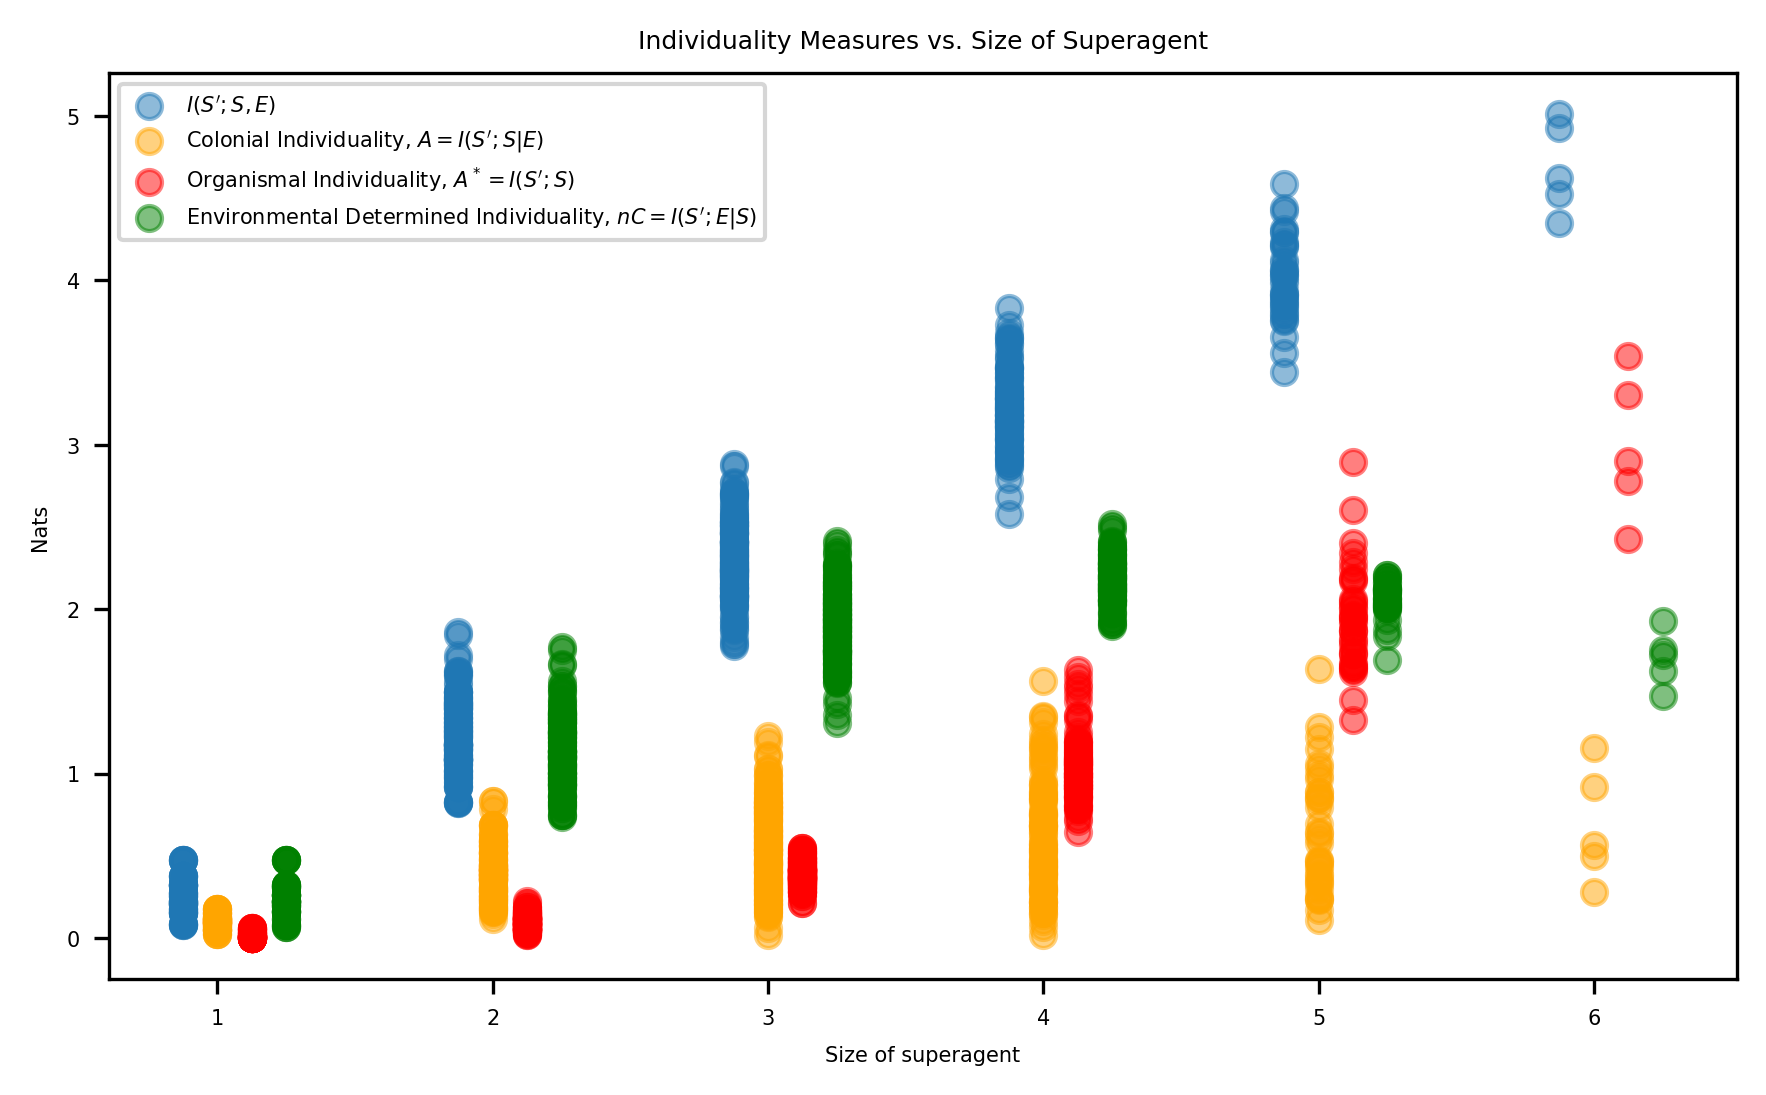

In [48]:
plt.figure(figsize=(7, 4), dpi=150)

plt.rcParams.update({'font.size': 5})

# I(S, E; S') ------------------------------------------------------------------
results_vanilla = []
for S_history, E_history in all_partition_timeseries:
    mi_estimator = JidtDiscreteMI()
    source = np.hstack((S_history[:-1], E_history[:-1]))
    target = S_history[1:]
    mi_result = mi_estimator.estimate(source, target)
    results_vanilla.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]-0.125 for r in results_vanilla]
y = [r[0] for r in results_vanilla]
plt.scatter(x, y, alpha=0.5, label="$I(S'; S, E)$")

# I(S'; S | E) --------------------------------------------------------------
results_colonial = []
for S_history, E_history in all_partition_timeseries:
    cmi_estimator = JidtDiscreteCMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=E_history[:-1])
    results_colonial.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1] for r in results_colonial]
y = [r[0] for r in results_colonial]
plt.scatter(x, y, alpha=0.5, c='orange', label="Colonial Individuality, $A = I(S'; S | E)$")

# I(S'; S | E) --------------------------------------------------------------
results_organismal = []
for S_history, E_history in all_partition_timeseries:
    mi_estimator = JidtDiscreteMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = mi_estimator.estimate(source, target)
    results_organismal.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]+0.125 for r in results_organismal]
y = [r[0] for r in results_organismal]
plt.scatter(x, y, alpha=0.5, c='red', label="Organismal Individuality, $A^*=I(S' ; S)$")

# I(S'; E | S) --------------------------------------------------------------
results_environmental = []
for S_history, E_history in all_partition_timeseries:
    cmi_estimator = JidtDiscreteCMI()
    source = E_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=S_history[:-1])
    results_environmental.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]+0.25 for r in results_environmental]
y = [r[0] for r in results_environmental]
plt.scatter(x, y, alpha=0.5, c='green', label="Environmental Determined Individuality, $nC=I(S'; E | S)$")

# Create a scatterplot ---------------------------------------------------------
plt.legend()
plt.ylabel('Nats')
plt.xlabel('Size of superagent')
plt.title('Individuality Measures vs. Size of Superagent')
plt.show()